In [1]:

import jax.numpy as jnp

import sys

sys.path.append("../../siegel_analyses/scripts/")
sys.path.insert(1,'../scripts/')

import netrep_helpers as nh
import utils
import loader
import setup
import pickle

import matplotlib.pyplot as plt

import seaborn as sns
%load_ext autoreload
%autoreload 2
import scipy.stats as sts
import numpy as np
import pandas as pd
import imp
imp.reload(setup)
imp.reload(loader)
imp.reload(utils)
import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import psychofit as psy

import matplotlib as mpl
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

### Functions

In [2]:
def convert_to_rw_choices(cs_trials):
    choices = []
    for subject in cs_trials:
        left = subject[:,:4] == -1
        right = subject[:,5:] == 1
        both = np.column_stack([left.astype(int), right.astype(int)])
        choices.append(np.mean(both,0))
    return np.array(choices)


In [3]:
def fit_psychmetric(cs, n_trials_total=None, dx=0.1):
    # Fit psychometric curves to each session
    contrasts = np.array([-100, -25, -12.5, -6.25, 0., 6.25, 12.5, 25., 100.])
    psym_pars = np.empty((len(cs), 4)) # psychometric parameters
    
    percent_right = np.empty((len(cs), len(contrasts)))

    xx = np.arange(-100, 100, dx)
    fit_curve = np.zeros((len(cs), len(xx)))

    for ii, percent_correct in enumerate(cs):
        """
        # Rempve since im converting to percent correct before
        behavior[behavior == -1] = 0
        percent_correct = np.nanmean(behavior == 1, axis=0)"""

        # Convert to percent choose right
        percent_right[ii,:] = np.hstack((1-percent_correct[contrasts < 0],
                                percent_correct[contrasts >= 0]))

        if n_trials_total is None:
            n_trials = [np.sum(~np.isnan(x)) for x in percent_correct.T]
        else:
            n_trials = [n_trials_total[ii]] * len(contrasts)

        # Format data for mle_fit_psycho
        # Row 1: conditions
        # Row 2: number of trials per condition
        # Row 3: percent left in each condition
        data = np.vstack((
            contrasts,
            n_trials,
            percent_right[ii,:]
        ))

        parmin = np.array([-20, -50, 0, 0])
        parmax = np.array([20, 50, 1, 1])
        psym_pars[ii,:], _ = \
            psy.mle_fit_psycho(data,
                               'erf_psycho_2gammas',
                               nfits=15,
                               parmin = parmin,
                               parmax = parmax)
        
        fit_curve[ii,:] = psy.erf_psycho_2gammas(psym_pars[ii,:], xx)

    return fit_curve, percent_right, psym_pars

def compute_behavioral_distance(cs, n_trials_total):
    fit_curve, percent_right, psycho_params = fit_psychmetric(cs, n_trials_total)

    dist_behavioral = np.array(
        [np.sqrt(np.sum((fit_curve[i,:] - fit_curve[j,:])**2 * 0.1))
        for i in range(len(cs))
        for j in range(len(cs))]).reshape(len(cs), len(cs))

    return dist_behavioral, psycho_params, percent_right



In [4]:

def get_dists(train_fold, test_fold, metric="sigmoid", n_trials_total=None):

    ys,cs = train_fold

    #if len(test_fold[1])!=0:
    _,cs = test_fold

    S = len(ys)

    #compute distance matrices
    dist_neural_list = utils.dsd([
        [ys[i],ys[j]]
        for i in range(len(ys)) 
        for j in range(i+1,len(ys))]
    ) # its a list, the shape is S*(S-1)/2

    # symmetrize the distance matrix
    dist_neural = np.zeros((S,S))
    dist_neural[np.triu_indices(S,1)] = dist_neural_list
    dist_neural = dist_neural + dist_neural.T

    if metric=="sigmoid":
        dist_cc,_,_ = compute_behavioral_distance(cs, n_trials_total=n_trials_total)
    elif metric=="area":
        dist_cc = np.zeros((S,S))

        for i in range(S):
            for j in range(S):
                #dist_cc[i,j] = np.mean(np.abs(cs[i]- cs[j]))
                dist_cc[i,j] = 1-sts.pearsonr(cs[i],cs[j])[0]

    return dist_neural,dist_cc,cs

def get_kneigh_decreasing(dist_neural,cs,S=10,W=2):
    """
    Compute the correlation between each subject behavior and average of the top K=2 neighbors in neural space
    cs: list of behavioral functions for each subject
    dist_neural: distance matrix between subjects in neural space
    S: number of subjects
    W: number of neighbors to consider
    returns all_preds_top: (19, 20) S - 1 x S
    """

    avg_cc = np.array(cs) #np.array([np.mean(c,0) for c in cs])
    all_preds_top = []

    for K in range(W,S+1):
        preds_top = []
        for subj in range(S):
            subj_idx =list(range(S))

            #ignore itself
            subj_idx.remove(subj)
            subj_idx = np.array(subj_idx)

            dists = dist_neural[subj][subj_idx] 
            sorted_idx  = subj_idx[np.argsort(dists)]

            s_dists=np.sort(dists)

            weights_top = np.exp(-s_dists[K-W:K])

            top_k = avg_cc[sorted_idx[K-W:K]] 
        
            preds_top.append(sts.pearsonr(np.mean(top_k,0),avg_cc[subj])[0])
            #preds_top.append(np.mean(np.abs(np.mean(top_k,0)-avg_cc[subj])))


        all_preds_top.append(preds_top)

    all_preds_top = np.array(all_preds_top)
    return all_preds_top



### Plot

In [5]:

# Relaxing also the number of folds and shuffles
n_folds = 50

all_c_corrs = []
all_preds_top = []

## Iterate over regions
regions = [ 'all', 'VISa','CA1', 'DG', 'LP', 'PO'] #, 'MRN',
#regions = ['VISa','VISam','VISp','MRN','LP']
#regions = ['CA1','DG','PO']

for region in regions:

    # For each fold, save the correlation between neural and behavioral distance, 
    # and the correlation between each subject's behavior and the average of its top K neighbors in neural space
    region_c_corr = []
    preds_top_region = []

    with open(f"100_folds_1_time_point_{region}.pkl","rb") as f:
        [params,train_data_folds,test_data_folds] = pickle.load(f)
    
    # Iterate over folds
    for fold in tqdm.trange(n_folds):

        train_fold, test_fold = train_data_folds[fold], test_data_folds[fold]

        try: 
            # Compute distance matrices on each fold
            dist_neural,dist_cc,cs = get_dists(train_fold,test_fold,n_trials_total=None,metric='area')
        except np.linalg.LinAlgError:
            print("linalg error")
            region_c_corr.append(r)
            preds_top_region.append(preds_top)
            continue
        
        # No need to save for this analysis

        #all_dist_neural.append(dist_neural)
        #all_dist_cc.append(dist_cc)
        
        S = dist_neural.shape[0]
        mask = np.triu_indices(S,1)
        flat_dist_neural = dist_neural[mask]
        flat_dist_cc = dist_cc[mask]

        r,_ = sts.pearsonr(flat_dist_cc,flat_dist_neural)
        region_c_corr.append(r)

        preds_top = get_kneigh_decreasing(dist_neural,cs,S)
        preds_top_region.append(preds_top)

        """# compute shuffled correlation
        corrs_shuffle = []
        flat_dist_cc_s =flat_dist_cc.copy()
        for _ in range(n_shuffles):
            np.random.shuffle(flat_dist_cc_s)
            r_s,_ = sts.pearsonr(flat_dist_cc_s,flat_dist_neural)
            corrs_shuffle.append(r_s)"""

    # Save results for this region
    all_preds_top.append(preds_top_region)
    all_c_corrs.append(np.array(region_c_corr))

  0%|          | 0/50 [00:00<?, ?it/s]2026-05-11 14:05:45,630	INFO worker.py:2013 -- Started a local Ray instance.
/home/blopes/.pyenv/versions/ibl/lib/python3.10/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
 42%|████▏     | 21/50 [00:55<01:06,  2.30s/it]

linalg error


 60%|██████    | 30/50 [00:52<00:31,  1.58s/it]

linalg error


100%|██████████| 50/50 [01:22<00:00,  1.64s/it]


In [56]:
n_subjs = np.shape(all_preds_top[0])[2]
_ids = list(range(n_subjs-1))*np.shape(all_preds_top[0])[0]

r=sts.linregress(_ids,np.nanmean(all_preds_top[0],2).reshape(-1))
r

LinregressResult(slope=np.float64(-0.0005439099822776896), intercept=np.float64(0.6139229320647654), rvalue=np.float64(-0.15192746900334983), pvalue=np.float64(1.1465253201997804e-15), stderr=np.float64(6.750118981024263e-05), intercept_stderr=np.float64(0.0021141993340052477))

In [18]:
pred_top_region_all = all_preds_top[0]
folds, k, s = np.shape(pred_top_region_all)
ids = list(range(s-1))*folds
mean_K = np.nanmean(pred_top_region_all,2).reshape(-1)

r = sts.linregress(ids, mean_K)
r


LinregressResult(slope=np.float64(7.126341925670836e-05), intercept=np.float64(0.2731664281947172), rvalue=np.float64(0.03965431873114951), pvalue=np.float64(0.03758405109867636), stderr=np.float64(3.4255165791824445e-05), intercept_stderr=np.float64(0.0010729032911405843))

In [6]:
## Create dataframe saving the correlations across folds and also the rvalues

# Here, the rvalues
r_region = []
slope_region = []
p_value_region = []
# Create dataframe for plotting 
for pred_top_region in all_preds_top:
    _, _, S = np.shape(pred_top_region) # number of subjects

    for f in range(n_folds):
        pred_top_region_f = pred_top_region[f] # shape (S-1, S)
        _ids = list(range(S-1)) # * S if not average? 

        # Average across all subjects? Or do not do that and flatten them all?
        mean_K_top = np.nanmean(pred_top_region_f, axis=1) # (S-1,)

        # Compute linear regression
        r = sts.linregress(_ids, mean_K_top)

        # Add the rvaule to the r list
        r_region.append(r.rvalue)
        slope_region.append(r.slope)
        p_value_region.append(r.pvalue)
    

lengths = [n_folds]*len(regions) 
region_info = pd.DataFrame({
    "region": np.repeat(regions, lengths),
    "corr": np.concatenate(all_c_corrs),
    "rvalue":np.array(r_region),
    "slope":np.array(slope_region),
})

/tmp/ipykernel_74699/3091685678.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="region", y="corr", data=region_info, order=regions, palette=palette, ax=axes[0], inner='quartile', color='lightgray', linewidth=1)
/tmp/ipykernel_74699/3091685678.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='region',y='rvalue',data=region_info, order=regions, palette=palette, ax=axes[1], inner='quartile', color='lightgray', linewidth=1)


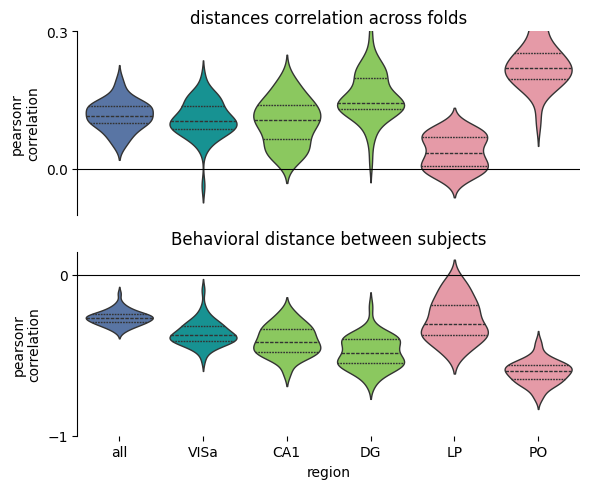

In [7]:
# Plot!!!
colors = ['#4C72B0', '#03A6A6', '#88D94E', '#88D94E', '#F28D9F', '#F28D9F', '#FF90FF']
#colors = ['#03A6A6', '#03A6A6', '#03A6A6', '#FF90FF', '#F28D9F']

palette = dict(zip(regions, colors))

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6,5))

# Plot distribution of correlations for each region
axes[0].set_title("distances correlation across folds", fontsize=12)

sns.violinplot(x="region", y="corr", data=region_info, order=regions, palette=palette, ax=axes[0], inner='quartile', color='lightgray', linewidth=1)
axes[0].axhline(0, color='k', linewidth=.8)
axes[0].set_ylabel("pearsonr\ncorrelation")
axes[0].set_yticks([0, 0.3])
axes[0].set_ylim(-0.1, 0.3)
axes[0].set_xticks([])
axes[0].set_xlabel('')
#sns.despine(ax=axes[0])

# Now plot the correlation between each subject's behavior and the average of its top K neighbors in neural space
axes[1].set_title("Behavioral distance between subjects", fontsize=12)

sns.violinplot(x='region',y='rvalue',data=region_info, order=regions, palette=palette, ax=axes[1], inner='quartile', color='lightgray', linewidth=1)
axes[1].axhline(0, color='k', linewidth=.8)
axes[1].set_ylabel("pearsonr\ncorrelation")
axes[1].set_yticks([-1 ,0])
#axes[1].set_ylim(-1,0.3)

plt.tight_layout()
sns.despine(bottom=True)
plt.savefig("IBL_regions_figure_response.svg",dpi=300)
plt.show()

In [8]:
# Checking the mean and confidence intervals of the correlations for each region
all_c_corrs_np = np.array(all_c_corrs)
print(np.mean(all_c_corrs_np,1))
print(np.percentile(all_c_corrs_np, [5,95], axis=1))

[0.11758511 0.1088959  0.10357178 0.15691778 0.03711098 0.22667813]
[[ 0.06322034  0.05587319  0.02766456  0.08275659 -0.01654368  0.16652398]
 [ 0.16972312  0.16526516  0.18305754  0.23652278  0.08890629  0.32019528]]


In [20]:
print(region_info.groupby('region')['rvalue'].mean())
print(region_info.groupby('region')['rvalue'].min())
print(region_info.groupby('region')['rvalue'].max())


region
CA1    -0.426930
DG     -0.496646
LP     -0.261765
PO     -0.622251
VISa   -0.368252
all    -0.265654
Name: rvalue, dtype: float64
region
CA1    -0.598032
DG     -0.657504
LP     -0.510172
PO     -0.793836
VISa   -0.558208
all    -0.353172
Name: rvalue, dtype: float64
region
CA1    -0.213405
DG     -0.255231
LP      0.019968
PO     -0.424667
VISa   -0.243339
all    -0.115708
Name: rvalue, dtype: float64


/tmp/ipykernel_74699/2893823100.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='region',y='slope',data=region_info, order=regions, palette=palette, ax=ax, inner='quartile', color='lightgray', linewidth=1)


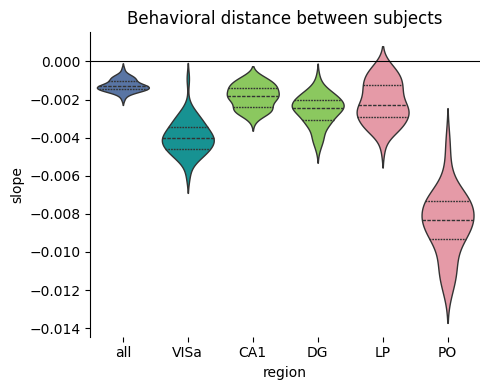

In [9]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))
ax.set_title("Behavioral distance between subjects", fontsize=12)

sns.violinplot(x='region',y='slope',data=region_info, order=regions, palette=palette, ax=ax, inner='quartile', color='lightgray', linewidth=1)
ax.axhline(0, color='k', linewidth=.8)
ax.set_ylabel("slope")

plt.tight_layout()
sns.despine(bottom=True)
plt.show()